In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import random
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/NLP-project/resume_data.csv'
df=pd.read_csv(file_path)
df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [ ]:
print("Dataset Shape:")
print(df.shape)
print("\nDataset Info:")
print(df.info())

Dataset Shape:
(9544, 35)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   address                              784 non-null    object 
 1   career_objective                     4740 non-null   object 
 2   skills                               9488 non-null   object 
 3   educational_institution_name         9460 non-null   object 
 4   degree_names                         9460 non-null   object 
 5   passing_years                        9460 non-null   object 
 6   educational_results                  9460 non-null   object 
 7   result_types                         9460 non-null   object 
 8   major_field_of_studies               9460 non-null   object 
 9   professional_company_names           9460 non-null   object 
 10  company_urls                         9460 non-null   ob

In [ ]:
print("Data Types:")
print(df.dtypes)

Data Types:
address                                 object
career_objective                        object
skills                                  object
educational_institution_name            object
degree_names                            object
passing_years                           object
educational_results                     object
result_types                            object
major_field_of_studies                  object
professional_company_names              object
company_urls                            object
start_dates                             object
end_dates                               object
related_skils_in_job                    object
positions                               object
locations                               object
responsibilities                        object
extra_curricular_activity_types         object
extra_curricular_organization_names     object
extra_curricular_organization_links     object
role_positions                          object
l

In [ ]:
missing_values = df.isnull().sum()
print("Missing values:")
print(missing_values[missing_values > 0])

print("\nBasic Statistics:")
print(df.describe())

Missing values:
address                                8760
career_objective                       4804
skills                                   56
educational_institution_name             84
degree_names                             84
passing_years                            84
educational_results                      84
result_types                             84
major_field_of_studies                   84
professional_company_names               84
company_urls                             84
start_dates                              84
end_dates                                84
related_skils_in_job                     84
positions                                84
locations                                84
extra_curricular_activity_types        6118
extra_curricular_organization_names    6118
extra_curricular_organization_links    6118
role_positions                         6118
languages                              8844
proficiency_levels                     8844
certification_pr

In [ ]:
text_columns = ['address', 'career_objective', 'skills', 'educational_institution_name',
                'degree_names', 'passing_years', 'educational_results', 'result_types',
                'major_field_of_studies', 'professional_company_names', 'company_urls',
                'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations',
                'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names',
                'extra_curricular_organization_links', 'role_positions', 'languages',
                'proficiency_levels', 'certification_providers', 'certification_skills',
                'online_links', 'issue_dates', 'expiry_dates', 'educationaL_requirements',
                'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required']
for col in text_columns:
  df[col] = df[col].fillna('Not Available')

missing_values_cleaned = df.isnull().sum()
print("Missing values after cleaning:")

print(missing_values_cleaned[missing_values_cleaned > 0])

Missing values after cleaning:
Series([], dtype: int64)


##Distribution of Matched Score
The matched score distribution showed that many resume-job pairs have moderate to high compatibility, which justifies the use of a meaningful threshold for binary classification.


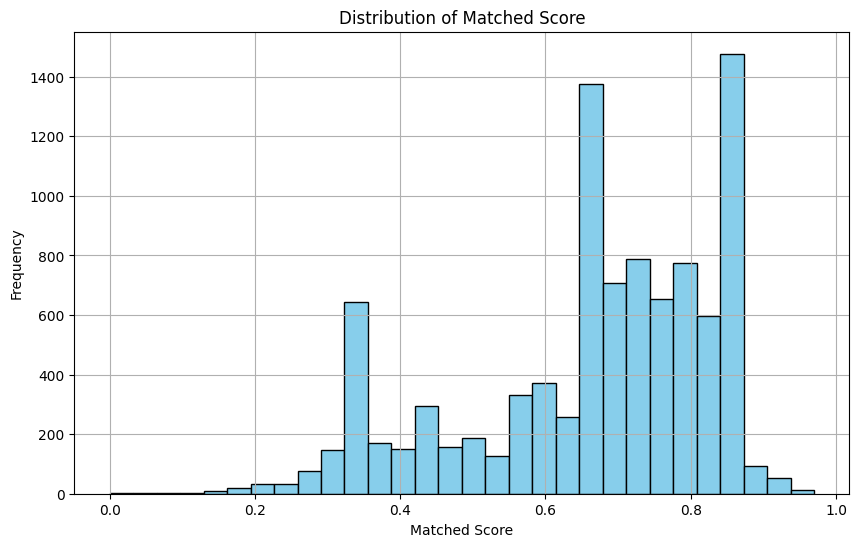

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df['matched_score'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Matched Score')
plt.xlabel('Matched Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

##Word Cloud for Career Objective
The word cloud generated from the career objective field showed highly frequent terms such as “machine learning”, “data science”, “learning”, “available”, “looking”, and “engineer”. This indicates that many candidates are aiming for roles related to data science, machine learning, and software development.

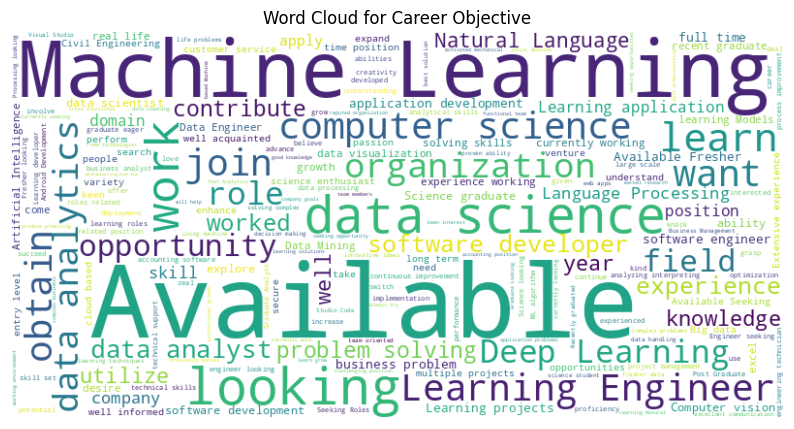

In [ ]:
text_data = ' '.join(df['career_objective'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Career Objective')
plt.axis('off')
plt.show()

##Top 20 Most Frequent Skills
The most common skills included “Python”, “Machine Learning”, “SQL”, “Excel”, “Deep Learning”, and “Java”. These skills reflect strong representation of technical and analytical job profiles in the dataset.

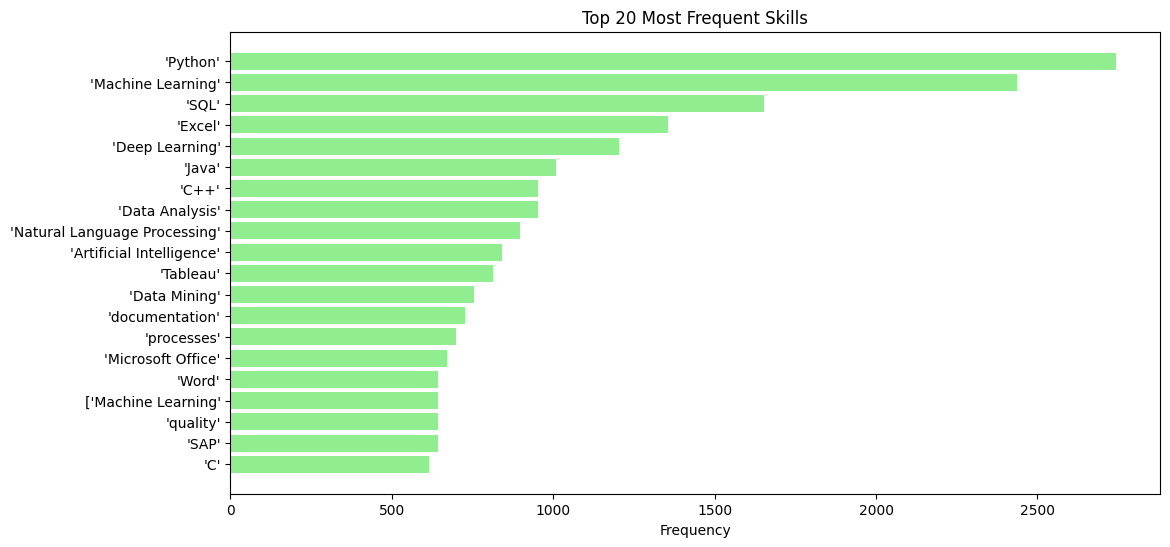

In [ ]:
skills_list = df['skills'].str.split(',').explode().dropna().str.strip()
skill_counts = Counter(skills_list)
top_skills = skill_counts.most_common(20)
skills, counts = zip(*top_skills)
plt.figure(figsize=(12, 6))
plt.barh(skills, counts, color='lightgreen')
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Skills')
plt.gca().invert_yaxis()
plt.show()

##Class Distribution
The class distribution confirmed a mild imbalance but no severe skew, supporting the use of standard classification models.


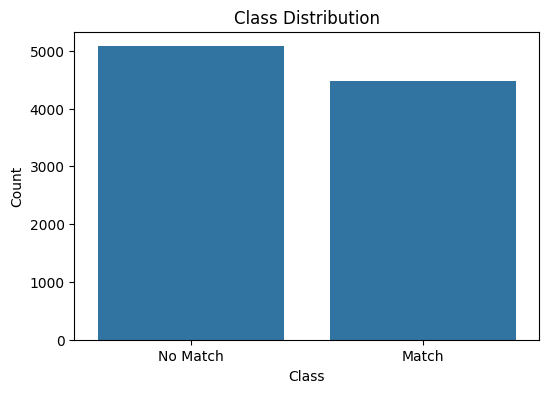

match
0    5075
1    4469
Name: count, dtype: int64
match
0    53.174769
1    46.825231
Name: proportion, dtype: float64


In [ ]:
df['match'] = (df['matched_score'] >= 0.7).astype(int)

plt.figure(figsize=(6,4))
sns.countplot(x='match', data=df)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0,1], ['No Match', 'Match'])
plt.show()

print(df['match'].value_counts())
print(df['match'].value_counts(normalize=True) * 100)

##Distribution of Text Length
The histogram for the career objective and skills fields showed that most candidates provide relatively compact descriptions, while a smaller number of entries are substantially longer.


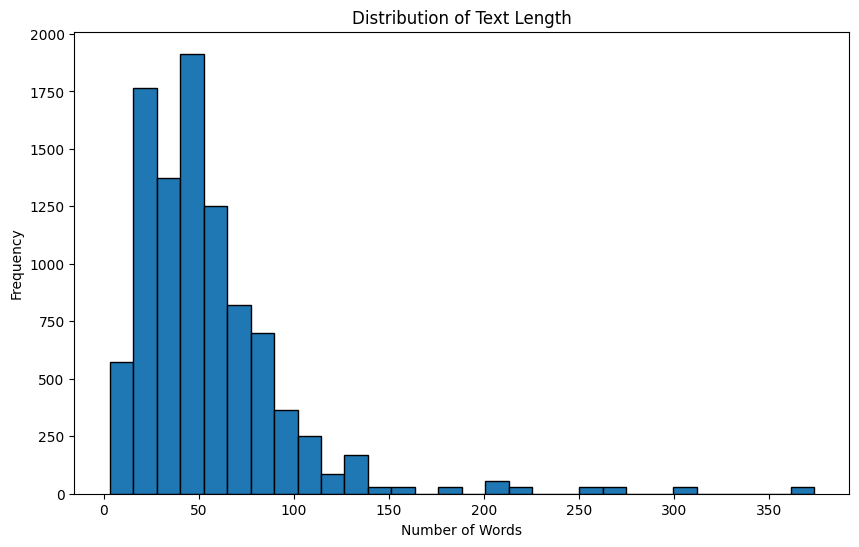

count    9544.000000
mean       55.341157
std        42.423978
min         3.000000
25%        28.000000
50%        48.000000
75%        66.000000
max       374.000000
Name: temp_text_length, dtype: float64


In [ ]:
df['temp_text'] = df['career_objective'].astype(str) + ' ' + df['skills'].astype(str)
df['temp_text_length'] = df['temp_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,6))
plt.hist(df['temp_text_length'], bins=30, edgecolor='black')
plt.title('Distribution of Text Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print(df['temp_text_length'].describe())

In [ ]:
#Vocabulary Size
all_words = ' '.join(df['combined_text'].astype(str)).split()
vocab_size = len(set(all_words))
print("Vocabulary size:", vocab_size)

Vocabulary size: 2385


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    tokens = word_tokenize(text)
    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words
    ]
    return ' '.join(lemmatized_tokens)

df['processed_career_objective'] = df['career_objective'].apply(preprocess_text)
print(df[['career_objective', 'processed_career_objective']].head())

                                    career_objective  \
0  Big data analytics working and database wareho...   
1  Fresher looking to join as a data analyst and ...   
2                                      Not Available   
3  To obtain a position in a fast-paced business ...   
4  Professional accountant with an outstanding wo...   

                          processed_career_objective  
0  big data analytics working database warehouse ...  
1  fresher looking join data analyst junior data ...  
2                                          available  
3  obtain position business office environment de...  
4  professional accountant outstanding work ethic...  


In [ ]:
text_columns = ['career_objective', 'skills', 'educational_institution_name',
                'degree_names', 'passing_years', 'educational_results',
                'result_types', 'major_field_of_studies', 'professional_company_names',
                'company_urls', 'related_skils_in_job', 'positions', 'locations',
                'responsibilities', 'extra_curricular_activity_types',
                'extra_curricular_organization_names', 'extra_curricular_organization_links',
                'role_positions', 'languages', 'proficiency_levels',
                'certification_providers', 'certification_skills',
                'online_links', 'issue_dates', 'expiry_dates', 'educationaL_requirements',
                'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'job_position_name']

for col in text_columns:
  df[f'processed_{col}'] = df[col].apply(preprocess_text)
print(df[['career_objective', 'processed_career_objective', 'skills', 'processed_skills']].head())

                                    career_objective  \
0  Big data analytics working and database wareho...   
1  Fresher looking to join as a data analyst and ...   
2                                      Not Available   
3  To obtain a position in a fast-paced business ...   
4  Professional accountant with an outstanding wo...   

                          processed_career_objective  \
0  big data analytics working database warehouse ...   
1  fresher looking join data analyst junior data ...   
2                                          available   
3  obtain position business office environment de...   
4  professional accountant outstanding work ethic...   

                                              skills  \
0  ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...   
1  ['Data Analysis', 'Data Analytics', 'Business ...   
2  ['Software Development', 'Machine Learning', '...   
3  ['accounts payables', 'accounts receivables', ...   
4  ['Analytical reasoning', 'Compliance testin

In [ ]:
df['combined_text'] = (
    df['processed_career_objective'] + ' ' +
    df['processed_skills'] + ' ' +
    df['processed_degree_names'] + ' ' +
    df['processed_major_field_of_studies'] + ' ' +
    df['processed_professional_company_names'] + ' ' +
    df['processed_related_skils_in_job'] + ' ' +
    df['processed_positions'] + ' ' +
    df['processed_responsibilities'] + ' ' +
    df['processed_job_position_name'] + ' ' +
    df['processed_educationaL_requirements'] + ' ' +
    df['processed_experiencere_requirement'] + ' ' +
    df['processed_responsibilities.1'] + ' ' +
    df['processed_skills_required']
)

print(df[['combined_text']].head())

                                       combined_text
0  big data analytics working database warehouse ...
1  fresher looking join data analyst junior data ...
2  available development learning learning assess...
3  obtain position business office environment de...
4  professional accountant outstanding work ethic...


In [ ]:
#Token Frequency Analysis
from collections import Counter
tokens = ' '.join(df['combined_text'].astype(str)).split()
token_counts = Counter(tokens)
print(token_counts.most_common(20))

[('management', 29585), ('name', 17976), ('development', 17769), ('analysis', 15742), ('data', 15262), ('science', 13943), ('learning', 13908), ('design', 12655), ('engineering', 11776), ('system', 10670), ('support', 10359), ('software', 9455), ('year', 9366), ('collaboration', 8970), ('engineer', 8368), ('available', 8345), ('maintenance', 7487), ('communication', 6903), ('documentation', 6670), ('database', 6650)]


In [ ]:
df['text_length'] = df['combined_text'].apply(lambda x: len(str(x).split()))

print(df['text_length'].describe())
print(df['matched_score'].value_counts())
print(df['matched_score'].value_counts(normalize=True) * 100)

count    9544.000000
mean      103.723072
std        36.976078
min        33.000000
25%        79.000000
50%        96.000000
75%       120.000000
max       365.000000
Name: text_length, dtype: float64

Match class counts:
match
0    5075
1    4469
Name: count, dtype: int64

Match class percentages:
match
0    53.174769
1    46.825231
Name: proportion, dtype: float64


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)
X_bigrams = bigram_vectorizer.fit_transform(df['combined_text'].astype(str))
bigram_counts = X_bigrams.toarray().sum(axis=0)

bigrams_df = pd.DataFrame({
    'Bigram': bigram_vectorizer.get_feature_names_out(),
    'Count': bigram_counts
}).sort_values(by='Count', ascending=False)

print(bigrams_df)

                         Bigram  Count
10             machine learning   4278
18           team collaboration   3410
3              computer science   3251
1              bachelor science   2752
16                  science bsc   2724
17          science engineering   2458
9                internal audit   2387
2       business administration   2335
4                 data analysis   2214
19            technical support   2132
6                   design data   2074
7             engineer bachelor   2044
14               model training   2042
12        management management   1999
0       application development   1924
15          resource management   1848
8                human resource   1792
5           database management   1787
11  maintenance troubleshooting   1705
13       mechanical engineering   1476


In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
combined_text_tfidf = tfidf.fit_transform(df['combined_text']).toarray()
combined_text_tfidf_df = pd.DataFrame(combined_text_tfidf, columns=tfidf.get_feature_names_out())
combined_text_tfidf_df.head()

,ability,able,academy,accepted,accepted auditing,access,access excel,access office,access outlook,access powerpoint,...,year project,year recruitment,year supervision,year technical,year technology,year trade,year year,york,zap,zeal
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.085333,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.067754,0.0,0.0,0.0,0.0
3,0.035231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0


In [ ]:
df['match'] = (df['matched_score'] >= 0.7).astype(int)
X = combined_text_tfidf_df
y = df['match']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (7635, 5000)
Test set shape: (1909, 5000)


In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print(f"Accuracy (Logistic Regression): {accuracy_lr:.2f}")
print(f"Precision (Logistic Regression): {precision_lr:.2f}")
print(f"Recall (Logistic Regression): {recall_lr:.2f}")
print(f"F1-Score (Logistic Regression): {f1_lr:.2f}")
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

Accuracy (Logistic Regression): 0.75
Precision (Logistic Regression): 0.72
Recall (Logistic Regression): 0.76
F1-Score (Logistic Regression): 0.74

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.78      0.74      0.76      1015
           1       0.72      0.76      0.74       894

    accuracy                           0.75      1909
   macro avg       0.75      0.75      0.75      1909
weighted avg       0.75      0.75      0.75      1909



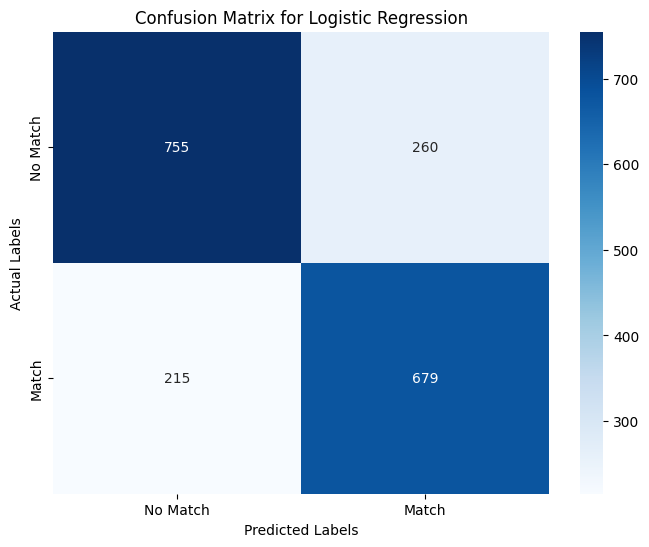

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap="Blues",
            xticklabels=["No Match", "Match"], yticklabels=["No Match", "Match"])
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
print(f"Accuracy (Random Forest): {accuracy_rf:.2f}")
print(f"Precision (Random Forest): {precision_rf:.2f}")
print(f"Recall (Random Forest): {recall_rf:.2f}")
print(f"F1-Score (Random Forest): {f1_rf:.2f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Accuracy (Random Forest): 0.78
Precision (Random Forest): 0.75
Recall (Random Forest): 0.78
F1-Score (Random Forest): 0.77

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.80      0.77      0.79      1015
           1       0.75      0.78      0.77       894

    accuracy                           0.78      1909
   macro avg       0.78      0.78      0.78      1909
weighted avg       0.78      0.78      0.78      1909



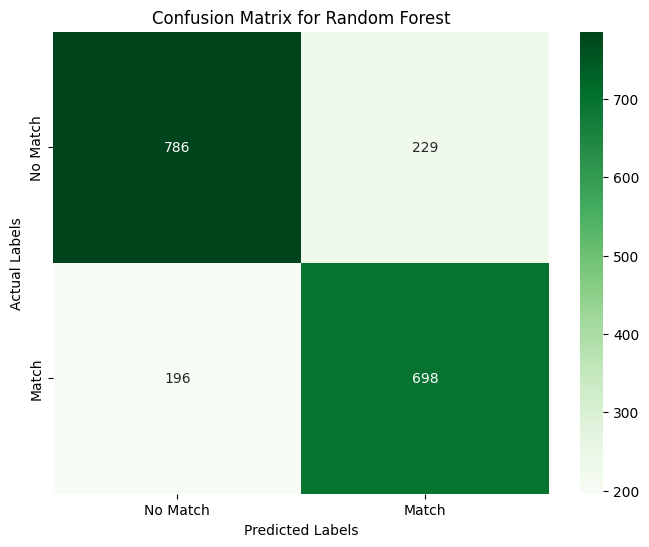

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Greens",
            xticklabels=["No Match", "Match"], yticklabels=["No Match", "Match"])
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

In [ ]:
importances = rf_model.feature_importances_
feature_names = combined_text_tfidf_df.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(feature_importance_df.head(20))

               Feature  Importance
2490              name    0.009408
4972              year    0.009283
2533         name name    0.007833
2058          learning    0.007782
2200        management    0.006364
920         compliance    0.005837
489          available    0.005227
4419            system    0.005096
1670           fresher    0.005050
251          analytics    0.003635
1420       engineering    0.003543
4064           science    0.003484
2171  machine learning    0.003358
1368          engineer    0.003333
171           analysis    0.003331
2109             least    0.003277
1187       development    0.003262
3999            review    0.003212
2170           machine    0.003174
1127            design    0.003078


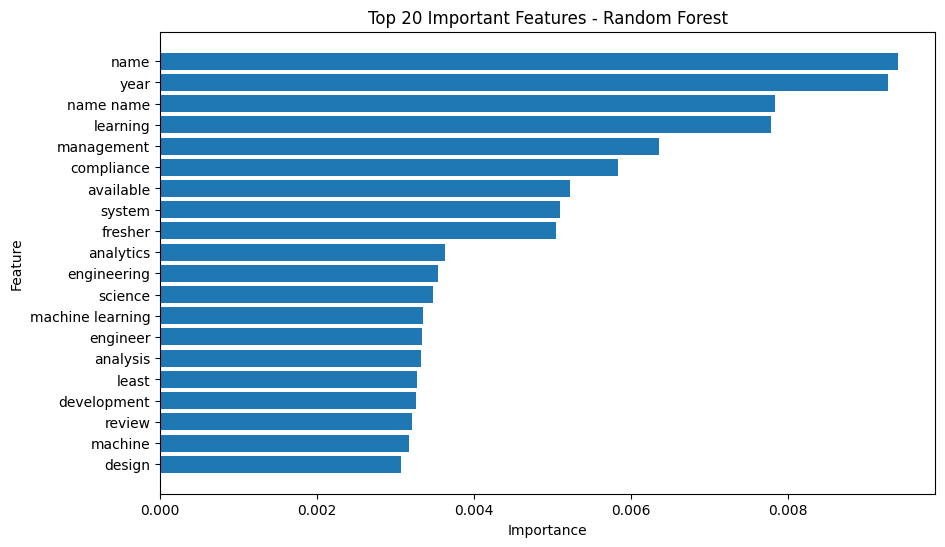

In [ ]:
top_features = feature_importance_df.head(20)
plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 20 Important Features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['combined_text'])
y = df['match']

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
rf = RandomForestClassifier(random_state=42)
param_dist = {
    'n_estimators':[50, 100, 150],
    'max_depth':[None, 10, 20],
    'min_samples_split':[2, 5],
    'min_samples_leaf': [1, 2]
}
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_tfidf, y_train)
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best Score: 0.7688792957626142


In [ ]:
best_rf = random_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_tfidf)
print("Accuracy (Tuned Random Forest):", accuracy_score(y_test, y_pred_best_rf))
print("Precision (Tuned Random Forest):", precision_score(y_test, y_pred_best_rf))
print("Recall (Tuned Random Forest):", recall_score(y_test, y_pred_best_rf))
print("F1-Score (Tuned Random Forest):", f1_score(y_test, y_pred_best_rf))

Accuracy (Tuned Random Forest): 0.7621791513881614
Precision (Tuned Random Forest): 0.7235772357723578
Recall (Tuned Random Forest): 0.796420581655481
F1-Score (Tuned Random Forest): 0.7582534611288605


In [ ]:
results_df = pd.DataFrame({
    'Model':['Logistic Regression', 'Random Forest'],
    'Accuracy':[accuracy_lr, accuracy_rf],
    'Precision':[precision_lr, precision_rf],
    'Recall':[recall_lr, recall_rf],
    'F1-Score':[f1_lr, f1_rf]
})
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.751179   0.723110  0.759508  0.740862
1        Random Forest  0.777370   0.752967  0.780761  0.766612


### Note
A BERT-based transformer model was considered, but training on the available CPU runtime was too slow for practical execution in Google Colab. Therefore, an LSTM-based deep learning model was used instead as the modern NLP approach.

In [ ]:
X = df['combined_text'].astype(str)
y = df['match'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("len(X_train):", len(X_train))
print("len(X_test):", len(X_test))
print("len(y_train):", len(y_train))
print("len(y_test):", len(y_test))

len(X_train): 7635
len(X_test): 1909
len(y_train): 7635
len(y_test): 1909


In [ ]:
max_words = 10000
max_len = 200
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (7635, 200)
X_test_pad shape: (1909, 200)


In [ ]:
lstm_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=max_words, output_dim=128),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,521 (5.08 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)
history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.5455 - loss: 0.6889 - val_accuracy: 0.5580 - val_loss: 0.6791
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - accuracy: 0.5527 - loss: 0.6879 - val_accuracy: 0.5521 - val_loss: 0.6848
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.5421 - loss: 0.6870 - val_accuracy: 0.5337 - val_loss: 0.6870


In [ ]:
y_pred_prob_lstm = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int).flatten()
print("y_test length:", len(y_test))
print("y_pred_lstm length:", len(y_pred_lstm))

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
y_test length: 1909
y_pred_lstm length: 1909


In [ ]:
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm = precision_score(y_test, y_pred_lstm)
recall_lstm = recall_score(y_test, y_pred_lstm)
f1_lstm = f1_score(y_test, y_pred_lstm)
print(f"Accuracy (LSTM): {accuracy_lstm:.2f}")
print(f"Precision (LSTM): {precision_lstm:.2f}")
print(f"Recall (LSTM): {recall_lstm:.2f}")
print(f"F1-Score (LSTM): {f1_lstm:.2f}")
print("\nClassification Report (LSTM):")
print(classification_report(y_test, y_pred_lstm))

Accuracy (LSTM): 0.56
Precision (LSTM): 0.77
Recall (LSTM): 0.08
F1-Score (LSTM): 0.15

Classification Report (LSTM):
              precision    recall  f1-score   support

           0       0.55      0.98      0.70      1015
           1       0.77      0.08      0.15       894

    accuracy                           0.56      1909
   macro avg       0.66      0.53      0.43      1909
weighted avg       0.65      0.56      0.44      1909



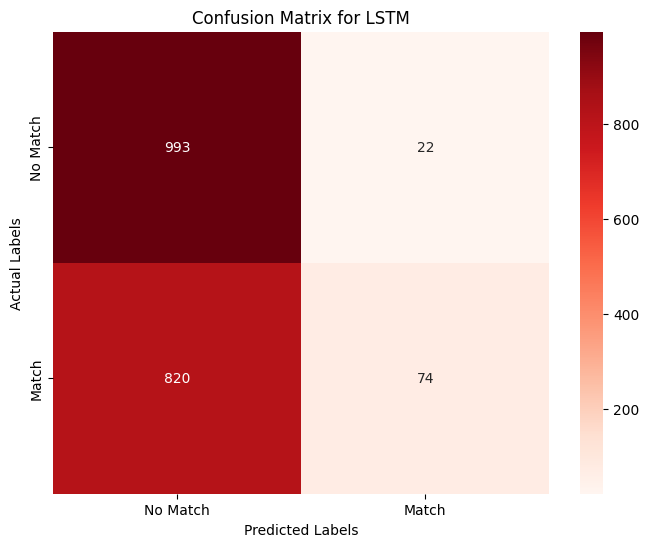

In [ ]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(8,6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Match', 'Match'],
            yticklabels=['No Match', 'Match']
)
plt.title("Confusion Matrix for LSTM")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

In [ ]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LSTM'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_lstm],
    'Precision': [precision_lr, precision_rf, precision_lstm],
    'Recall': [recall_lr, recall_rf, recall_lstm],
    'F1-Score': [f1_lr, f1_rf, f1_lstm]
})
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.751179   0.723110  0.759508  0.740862
1        Random Forest  0.777370   0.752967  0.780761  0.766612
2                 LSTM  0.558931   0.770833  0.082774  0.149495


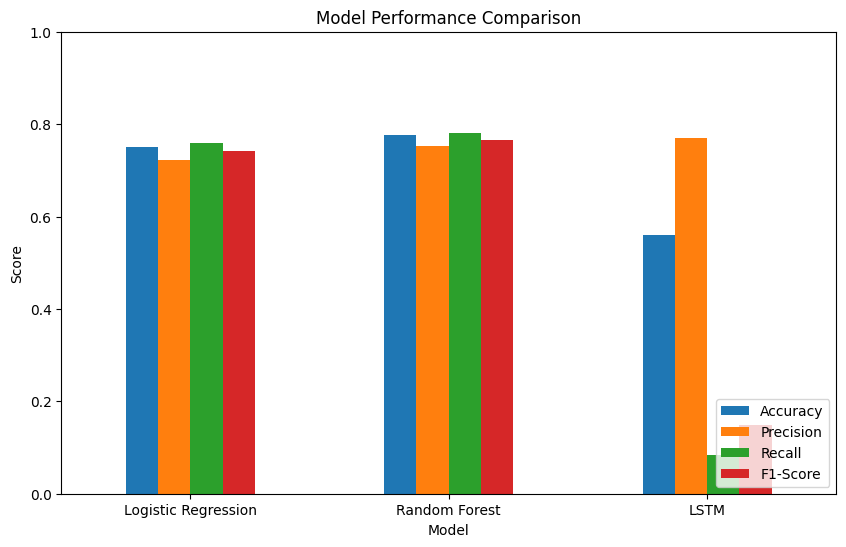

In [ ]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar',
    figsize=(10,6)
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [ ]:
#Using the best model, which is Random Forest
error_analysis_rf = pd.DataFrame({
    'combined_text':X_test,
    'actual': y_test,
    'predicted': y_pred_rf
})
rf_errors = error_analysis_rf[error_analysis_rf['actual'] != error_analysis_rf['predicted']]
print(rf_errors.head(5))

                                          combined_text  actual  predicted
2918  available support appointment administration b...       1          0
9530  pursue excellence dynamic business world obtai...       1          0
8903  available  computer science equivalent msc com...       0          1
9148  available management management analysis desig...       0          1
716   experienced senior corporate accountant dedica...       0          1
